# Toy Model for Stellarator Island Divertor Plate 3D Monte Carlo Simulator
This notebook is of a first 2D toy model to ensure the math (particle flow along field lines and MC diffusion) is done correctly

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# Setup
Lx = 1; Ly = 1 # [m]
dx = 0.01; dy = 0.01 # [m]

def B_field(r):
    x = r[:,0]
    y = r[:,1]
    B = np.zeros_like(r)
    B[:,0] = 1
    B[:,1] = 0
    return B

D_perp = 10**(-4) # perpendicular diffusion coefficient [m^2/s]
v_par = 1 # parallel advection velocity [m/s]

In [23]:
# Update Step Definition
def update_step(r, dt = 0.001): # dt has units [s]
    B = B_field(r)
    B_mag = np.linalg.norm(B, axis= 1)
    b = B / B_mag[:,None]
    p = (np.array([[0,-1],[1,0]]) @ B.T).T

    # parallel advection
    dr_adv = v_par * dt * b

    # diffusive drift
    dr_drift = np.sqrt(2*D_perp*dt) * np.random.normal(size= r.shape[0])[:,None] * p

    r[:,0] = (r[:,0] + dr_adv[:,0] + dr_drift[:,0])%Lx
    r[:,1] = (r[:,1] + dr_adv[:,1] + dr_drift[:,1])%Ly
    return r

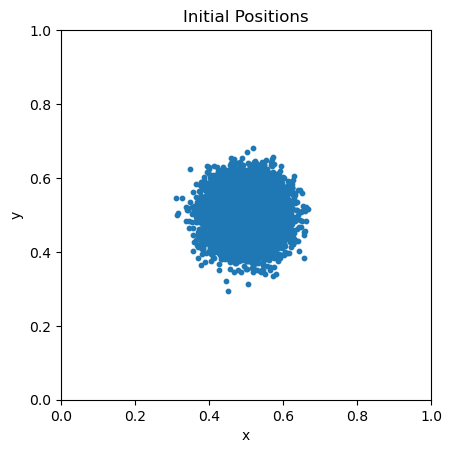

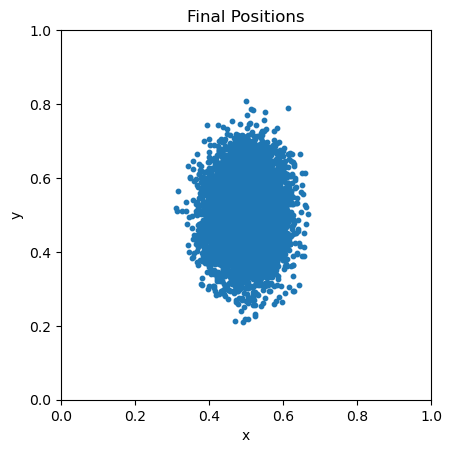

In [18]:
n = 10000
rs = 0.5 * np.ones((n,2))
rs += 0.05 * np.random.randn(n,2) # add some gaussian noise to initial positions
steps = 2000

plt.scatter(rs[:,0], rs[:,1], s= 10)
plt.title("Initial Positions")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.gca().set_aspect("equal")
plt.show()

r_i = rs.copy()

pos = []
updates = []
for i in range(steps):
    rs_prev = rs.copy()
    rs = update_step(rs, dt = 0.01)
    pos.append(rs.copy())
    updates.append(rs-rs_prev)
    # if i % 1000 == 0: print(rs-rs_prev)
pos = np.array(pos)
updates = np.array(updates)


plt.scatter(rs[:,0], rs[:,1], s = 10)
plt.title("Final Positions")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.gca().set_aspect("equal")
plt.show()

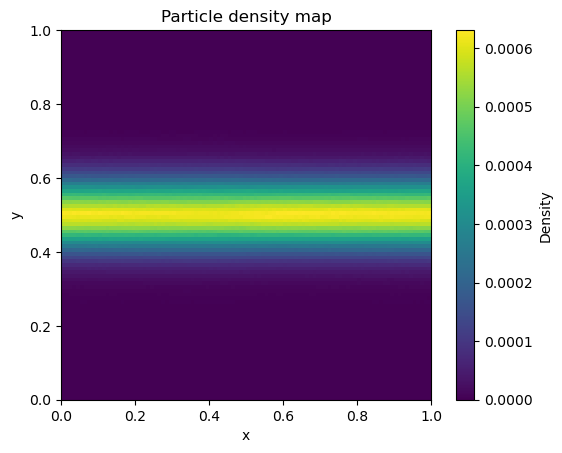

In [19]:
x_edges = np.arange(0, Lx + dx, dx)
y_edges = np.arange(0, Ly + dy, dy)

x_centers = x_edges[:-1] + dx / 2
y_centers = y_edges[:-1] + dy / 2
X, Y = np.meshgrid(x_centers, y_centers, indexing="ij")

cnts = np.zeros((len(x_centers), len(y_centers)))

all_x = pos[:, :, 0].ravel()
all_y = pos[:, :, 1].ravel()
cnts, x_edges, y_edges = np.histogram2d(
    all_x, all_y, bins=[len(x_centers), len(y_centers)], range=[[0, Lx], [0, Ly]]
)
cnts = cnts / np.sum(cnts)

h = cnts.copy()
img = plt.pcolormesh(X, Y, cnts, cmap="viridis")
plt.colorbar(img, label="Density")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Particle density map")
plt.gca().set_aspect("equal")

In [24]:
def compute_density_grid(n_particles, steps=1000, dt=0.01):
    rs = 0.5 * np.ones((n_particles, 2))
    rs += 0.05 * np.random.randn(n_particles, 2)
    
    pos = np.empty((steps, n_particles, 2))
    for i in range(steps):
        rs = update_step(rs, dt=dt)
        pos[i] = rs

    x_edges = np.arange(0, Lx + dx, dx)
    y_edges = np.arange(0, Ly + dy, dy)
    
    cnts, _, _ = np.histogram2d(
        pos[:, :, 0].ravel(),
        pos[:, :, 1].ravel(),
        bins=[x_edges, y_edges]
    )

    return cnts / np.sum(cnts)

In [ ]:
n_list = [500, 2000, 8000, 32000, 128000]
n_ref = 500000
steps = 200
dt = 0.01

ref_grid = compute_density_grid(n_ref, steps=steps, dt=dt)

l1_errors = []
l_inf_errors = []

for n in n_list:
    grid_n = compute_density_grid(n, steps=steps, dt=dt)
    
    diff = np.abs(grid_n - ref_grid)
    
    
    err_l1 = np.sum(diff) # L1 norm
    err_linf = np.max(diff) # L_inf norm
    
    l1_errors.append(err_l1)
    l_inf_errors.append(err_linf)
    
    print(f"N = {n:7d} | L1 Grid Error: {err_l1:.5f} | Max Cell Error: {err_linf:.6f}")

Generating high-N reference grid (N = 500000)...

--- Density Grid Self-Convergence ---
N =     500 | L1 Grid Error: 0.13468 | Max Cell Error: 0.000247
N =    2000 | L1 Grid Error: 0.06995 | Max Cell Error: 0.000140
N =    8000 | L1 Grid Error: 0.03850 | Max Cell Error: 0.000099
N =   32000 | L1 Grid Error: 0.02155 | Max Cell Error: 0.000037
N =  128000 | L1 Grid Error: 0.00951 | Max Cell Error: 0.000017


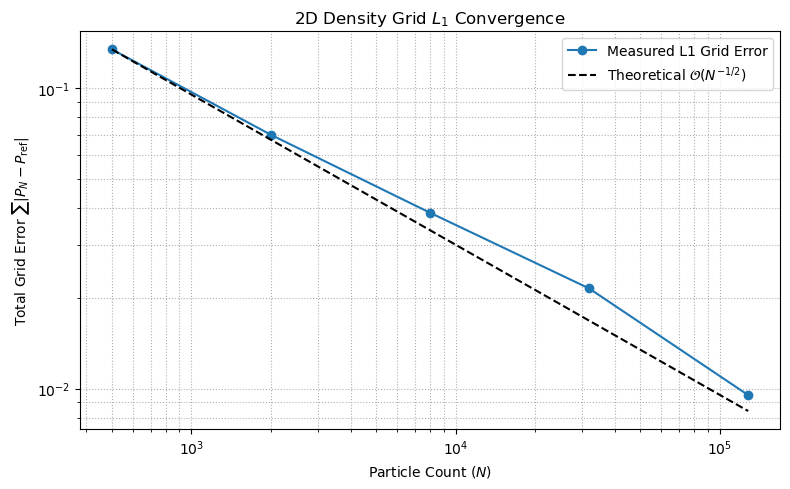

In [31]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

# Plot L1 error
ax1.loglog(n_list, l1_errors, "o-", color="tab:blue", label="Measured L1 Grid Error")
ref_slope = l1_errors[0] * np.sqrt(n_list[0]) / np.sqrt(n_list)
ax1.loglog(n_list, ref_slope, "k--", label=r"Theoretical $\mathcal{O}(N^{-1/2})$")
ax1.set_xlabel("Particle Count ($N$)")
ax1.set_ylabel(r"Total Grid Error $\sum |P_N - P_{\mathrm{ref}}|$")
ax1.set_title("2D Density Grid $L_1$ Convergence")
ax1.grid(True, which="both", ls=":")
ax1.legend()

plt.tight_layout()
plt.show()